# Pharmacogenomic Signal Enrichment
Cross-referencing FAERS adverse event signals with PharmGKB variant-drug-phenotype annotations.

**Question:** Do drugs with known pharmacogenomic risk variants show disproportionately
stronger FAERS signals for their genotype-predicted AEs?

**Data:** 58,368 FAERS signals (252 drugs, 8 quarters) × 5,186 PharmGKB clinical annotations (871 drugs)

In [1]:
import sys, os
from pathlib import Path
root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pipeline import PGxEnrichment

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

FIGURES_DIR = Path('data/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load data
signals = pd.read_csv('data/signals_pgx_drugs.csv')
pgx_raw = pd.read_parquet('data/pharmgkb/clinical_annotations_raw.parquet')

# Fix PharmGKB delimiter and re-parse
pgx_raw.columns = [c.strip().replace(' ','_').replace('/','_').upper() for c in pgx_raw.columns]
drug_col = [c for c in pgx_raw.columns if 'DRUG' in c and 'SEQ' not in c][0]
phen_col = [c for c in pgx_raw.columns if 'PHENOTYPE' in c and 'CATEGORY' not in c][0]

pgx_raw['DRUG'] = pgx_raw[drug_col].fillna('').str.split(';').apply(lambda x: [s.strip().upper() for s in x])
pgx = pgx_raw.explode('DRUG')
pgx = pgx[pgx['DRUG'].str.len() > 0].copy()

# Normalize phenotype
pgx['PHENOTYPE_NORM'] = (pgx[phen_col].fillna('')
                         .str.upper().str.strip()
                         .str.replace(r'[^\w\s]',' ',regex=True)
                         .str.replace(r'\s+',' ',regex=True).str.strip())

# Evidence score
ev_order = {'1A':6,'1B':5,'2A':4,'2B':3,'3':2,'4':1}
ev_col = [c for c in pgx.columns if 'EVIDENCE' in c and 'LEVEL' in c][0]
pgx = pgx.rename(columns={ev_col:'EVIDENCE_LEVEL'})
pgx['EVIDENCE_SCORE'] = pgx['EVIDENCE_LEVEL'].map(ev_order).fillna(0)

# Rename phenotype category
pcat_col = [c for c in pgx.columns if 'PHENOTYPE_CATEGORY' in c]
if pcat_col:
    pgx = pgx.rename(columns={pcat_col[0]:'PHENOTYPE_CATEGORY'})

# Gene column
if 'GENE' not in pgx.columns:
    gene_col = [c for c in pgx.columns if c.startswith('GENE')]
    if gene_col:
        pgx = pgx.rename(columns={gene_col[0]:'GENE'})

print(f'Signals: {len(signals):,} rows | {signals["DRUG"].nunique()} drugs')
print(f'PharmGKB: {len(pgx):,} rows | {pgx["DRUG"].nunique()} drugs')
print(f'Evidence distribution:')
print(pgx['EVIDENCE_LEVEL'].value_counts().to_string())

Signals: 58,368 rows | 252 drugs
PharmGKB: 7,013 rows | 658 drugs
Evidence distribution:
EVIDENCE_LEVEL
3     5976
1A     566
4      369
2A      48
2B      29
1B      25


## 1. PharmGKB Database Overview

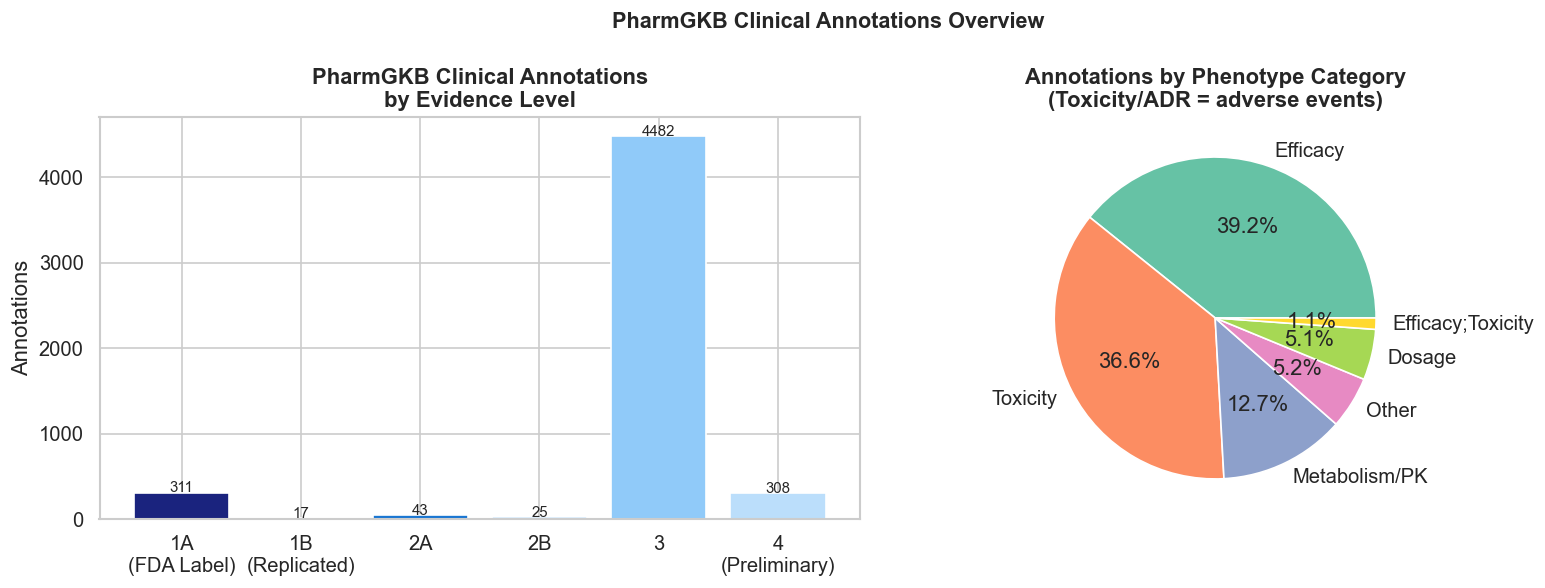


Toxicity/ADR annotations: 1,955

Top genes with toxicity annotations:
GENE
RYR1        318
ABCB1       101
HLA-B        89
OPRM1        89
DPYD         60
PIK3R2       39
ABCC2        38
NAT2         37
SLCO1B1      37
COMT         33
HLA-DRB1     33
ERCC1        29
UGT1A1       29
DRD2         28
CYP2D6       27


In [2]:
# ── Evidence level distribution ───────────────────────────────────────────────
ev_labels = {'1A':'1A\n(FDA Label)','1B':'1B\n(Replicated)','2A':'2A','2B':'2B','3':'3','4':'4\n(Preliminary)'}
ev_counts = pgx.drop_duplicates('CLINICAL_ANNOTATION_ID')['EVIDENCE_LEVEL'].value_counts().reindex(ev_labels.keys()).dropna()
cat_counts = pgx.drop_duplicates('CLINICAL_ANNOTATION_ID')['PHENOTYPE_CATEGORY'].value_counts().head(6)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

colors_ev = ['#1a237e','#1565c0','#1976d2','#42a5f5','#90caf9','#bbdefb']
axes[0].bar([ev_labels.get(k,k) for k in ev_counts.index], ev_counts.values, color=colors_ev[:len(ev_counts)])
axes[0].set_ylabel('Annotations')
axes[0].set_title('PharmGKB Clinical Annotations\nby Evidence Level', fontweight='bold')
for i, val in enumerate(ev_counts.values):
    axes[0].text(i, val+5, str(val), ha='center', fontsize=9)

axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2',len(cat_counts)))
axes[1].set_title('Annotations by Phenotype Category\n(Toxicity/ADR = adverse events)', fontweight='bold')

plt.suptitle('PharmGKB Clinical Annotations Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_pharmgkb_overview.png')
plt.show()

# Top genes with toxicity annotations
tox = pgx[pgx['PHENOTYPE_CATEGORY'].str.contains('Toxicity', na=False)]
print(f'\nToxicity/ADR annotations: {len(tox.drop_duplicates("CLINICAL_ANNOTATION_ID")):,}')
print(f'\nTop genes with toxicity annotations:')
print(tox['GENE'].value_counts().head(15).to_string())

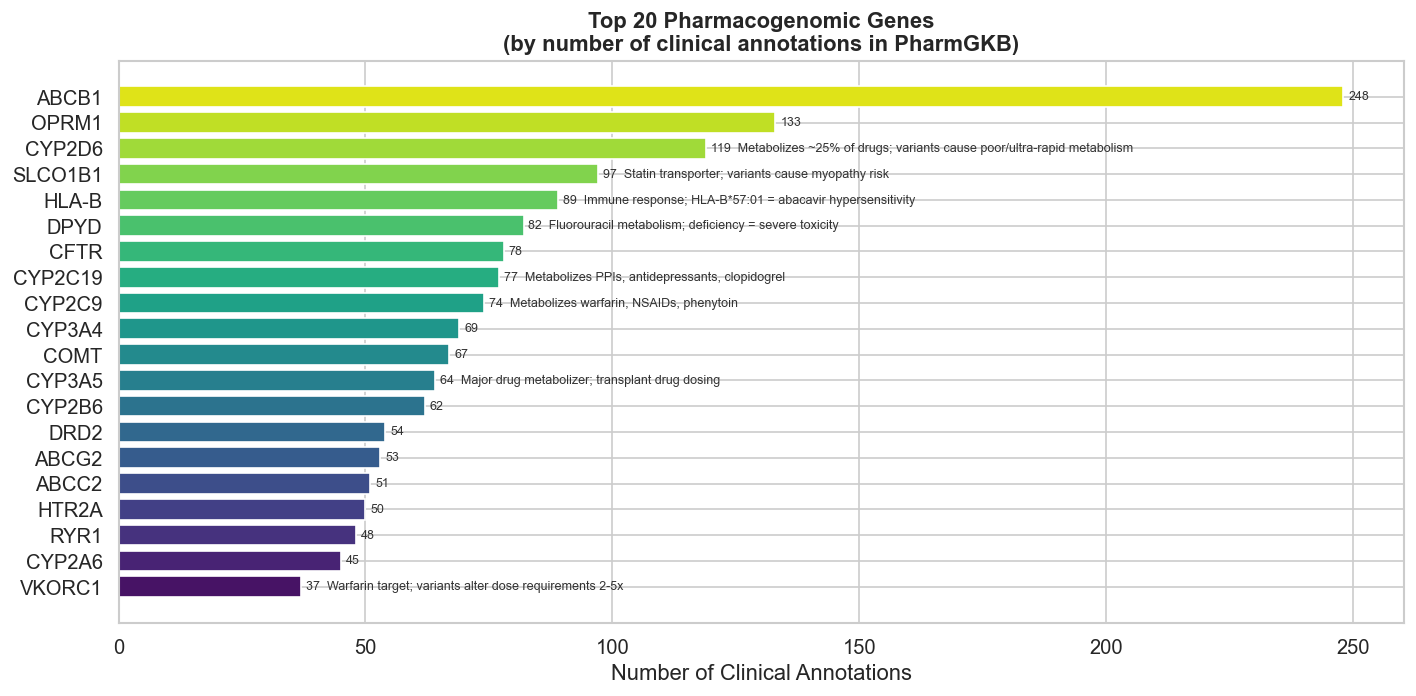

In [3]:
# ── Top pharmacogenomic genes ─────────────────────────────────────────────────
gene_counts = pgx.drop_duplicates('CLINICAL_ANNOTATION_ID')['GENE'].value_counts().head(20)

# Gene annotation (the biology behind the top genes)
gene_notes = {
    'CYP2D6':  'Metabolizes ~25% of drugs; variants cause poor/ultra-rapid metabolism',
    'CYP2C19': 'Metabolizes PPIs, antidepressants, clopidogrel',
    'CYP2C9':  'Metabolizes warfarin, NSAIDs, phenytoin',
    'VKORC1':  'Warfarin target; variants alter dose requirements 2-5x',
    'SLCO1B1': 'Statin transporter; variants cause myopathy risk',
    'DPYD':    'Fluorouracil metabolism; deficiency = severe toxicity',
    'TPMT':    'Thiopurine metabolism; deficiency = myelosuppression',
    'HLA-B':   'Immune response; HLA-B*57:01 = abacavir hypersensitivity',
    'CYP3A5':  'Major drug metabolizer; transplant drug dosing',
    'CYP1A2':  'Caffeine, clozapine, theophylline metabolism',
}

fig, ax = plt.subplots(figsize=(12,6))
colors_gene = sns.color_palette('viridis', len(gene_counts))
bars = ax.barh(gene_counts.index[::-1], gene_counts.values[::-1], color=colors_gene)
ax.set_xlabel('Number of Clinical Annotations')
ax.set_title('Top 20 Pharmacogenomic Genes\n(by number of clinical annotations in PharmGKB)', fontweight='bold')
for i, (gene, val) in enumerate(zip(gene_counts.index[::-1], gene_counts.values[::-1])):
    note = gene_notes.get(gene, '')
    label = f'{val}  {note}' if note else str(val)
    ax.text(val+1, i, label, va='center', fontsize=7.5, color='#333')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_top_pgx_genes.png')
plt.show()

## 2. Enrichment Analysis

For each drug present in both FAERS and PharmGKB, we join on drug name + phenotype similarity,
then test whether genomically-annotated AEs show higher ROR than unannotated AEs.

**Match confidence scores:**
- 1.0 = exact term match
- 0.9 = one term contains the other
- 0.8 = synonym map match (e.g. 'bleeding' = 'haemorrhage')
- 0.5-0.85 = token overlap (Jaccard similarity)
- <0.5 = excluded

In [4]:
# ── Run enrichment join ────────────────────────────────────────────────────────
enricher = PGxEnrichment(signals, pgx, min_evidence_score=1)  # include all evidence levels
joined = enricher.join(min_match_confidence=0.4)  # start permissive, filter later

print(f'Matched pairs: {len(joined):,}')
if not joined.empty:
    print(f'Drugs with matches: {joined["DRUG"].nunique()}')
    print(f'\nMatch confidence distribution:')
    print(pd.cut(joined['MATCH_CONFIDENCE'], bins=[0,.5,.7,.9,1.01],
                 labels=['0.4-0.5','0.5-0.7','0.7-0.9','0.9-1.0']).value_counts().sort_index().to_string())
    print(f'\nTop 20 by convergence score:')
    cols = ['DRUG','PT','n_reports','ROR','EVIDENCE_LEVEL','PGX_GENE','PGX_PHENOTYPE','MATCH_CONFIDENCE','CONVERGENCE_SCORE']
    cols = [c for c in cols if c in joined.columns]
    print(joined[cols].head(20).to_string(index=False))
    joined.to_csv('data/enrichment_results.csv', index=False)
    print(f'\nSaved to data/enrichment_results.csv')

INFO - Signals: 58,368 rows, 252 drugs


INFO - PGx annotations (evidence >= 1): 7,013 rows


INFO - Drugs in both datasets: 252 — ['ABACAVIR', 'ABIRATERONE', 'ACETAMINOPHEN', 'ACETAZOLAMIDE', 'ACETYLCYSTEINE', 'ADALIMUMAB', 'ALEMTUZUMAB', 'ALLOPURINOL', 'ALPRAZOLAM', 'AMANTADINE']...


INFO - Matched 2,163 drug-AE pairs across 187 drugs


Matched pairs: 2,163
Drugs with matches: 187

Match confidence distribution:
MATCH_CONFIDENCE
0.4-0.5    984
0.5-0.7    583
0.7-0.9    483
0.9-1.0    113

Top 20 by convergence score:
        DRUG                                                    PT  n_reports         ROR EVIDENCE_LEVEL PGX_GENE                                                                                                                                                      PGX_PHENOTYPE  MATCH_CONFIDENCE  CONVERGENCE_SCORE
  TACROLIMUS              PROPHYLAXIS AGAINST TRANSPLANT REJECTION         19         inf              4   CYP3A5                                                                                                                                               TRANSPLANT REJECTION              0.90                inf
 SUMATRIPTAN                          CONGENITAL HORNER'S SYNDROME          4         inf              3    OPRM1                                                                           

In [5]:
# ── Statistical enrichment test ───────────────────────────────────────────────
if not joined.empty:
    enrich_test = enricher.enrichment_test(joined)
    print('Enrichment test results (Mann-Whitney U):')
    print(enrich_test.to_string(index=False))
    enrich_test.to_csv('data/enrichment_test_results.csv', index=False)

INFO - Enrichment test: 30/147 drugs show significant PGx enrichment


Enrichment test results (Mann-Whitney U):
                         DRUG  n_pgx_annotated_aes  n_unannotated_aes  median_ror_annotated  median_ror_unannotated  ror_fold_enrichment  mannwhitney_u  p_value  significant                                                      interpretation  p_value_fdr_bh  p_value_bonferroni  significant_fdr  significant_bonferroni
                  BEVACIZUMAB                   34                786                 19.40                    6.90                 2.81        18914.0   0.0000         True Genomically-annotated AEs show significantly higher reporting rates          0.0000              0.0000             True                    True
                    RITUXIMAB                   63               1280                  8.84                    4.24                 2.09        58465.5   0.0000         True Genomically-annotated AEs show significantly higher reporting rates          0.0000              0.0000             True                    True
 

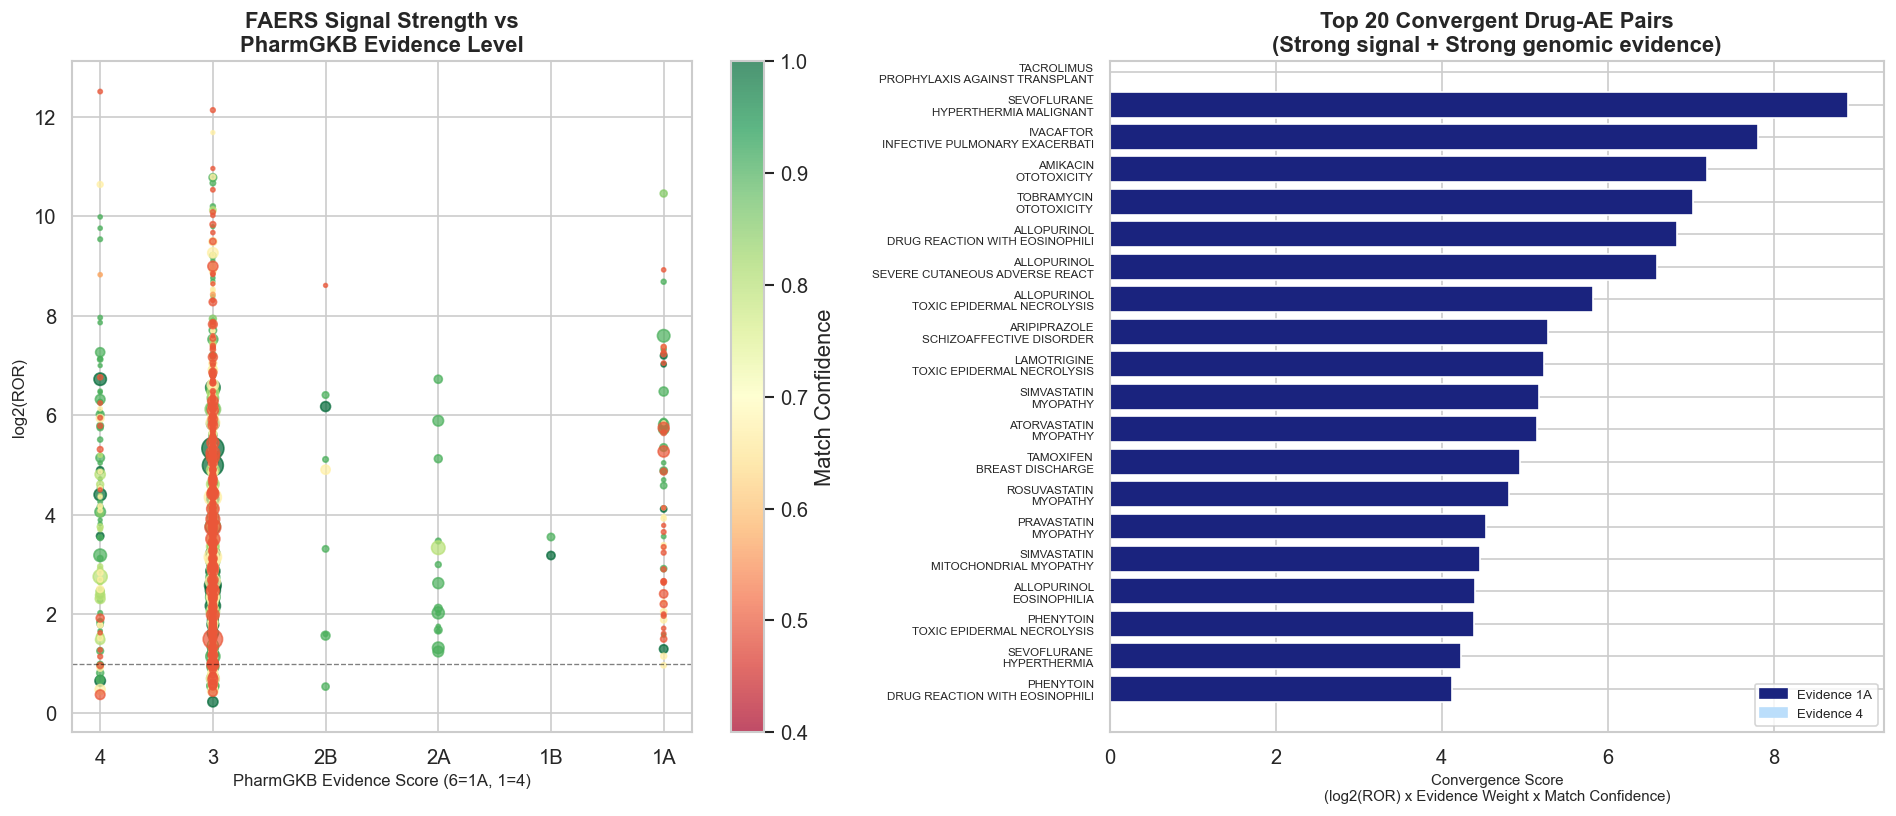

In [6]:
# ── Convergence score visualization ──────────────────────────────────────────
if not joined.empty:
    # Filter to high-confidence matches for visualization
    high_conf = joined[joined['MATCH_CONFIDENCE'] >= 0.5].copy()
    
    if len(high_conf) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # Scatter: ROR vs Evidence Score, sized by report count, colored by match confidence
        sc = axes[0].scatter(
            high_conf['EVIDENCE_SCORE'],
            np.log2(high_conf['ROR'].clip(0.1)),
            c=high_conf['MATCH_CONFIDENCE'],
            s=np.sqrt(high_conf['n_reports'].clip(1))*3,
            cmap='RdYlGn', alpha=0.7, vmin=0.4, vmax=1.0
        )
        plt.colorbar(sc, ax=axes[0], label='Match Confidence')
        axes[0].axhline(1, color='black', linestyle='--', lw=0.8, alpha=0.5, label='ROR=2')
        axes[0].set_xlabel('PharmGKB Evidence Score (6=1A, 1=4)', fontsize=10)
        axes[0].set_ylabel('log2(ROR)', fontsize=10)
        axes[0].set_title('FAERS Signal Strength vs\nPharmGKB Evidence Level', fontweight='bold')
        axes[0].set_xticks([1,2,3,4,5,6])
        axes[0].set_xticklabels(['4','3','2B','2A','1B','1A'])
        
        # Top convergence scores bar chart
        top_conv = high_conf.nlargest(20, 'CONVERGENCE_SCORE')
        top_conv['label'] = top_conv['DRUG'] + '\n' + top_conv['PT'].str[:30]
        
        color_by_ev = {'1A':'#1a237e','1B':'#1565c0','2A':'#1976d2','2B':'#42a5f5','3':'#90caf9','4':'#bbdefb'}
        bar_colors = top_conv['EVIDENCE_LEVEL'].map(color_by_ev).fillna('#cccccc')
        
        axes[1].barh(range(len(top_conv)), top_conv['CONVERGENCE_SCORE'].values[::-1],
                     color=bar_colors.values[::-1])
        axes[1].set_yticks(range(len(top_conv)))
        axes[1].set_yticklabels(top_conv['label'].values[::-1], fontsize=7)
        axes[1].set_xlabel('Convergence Score\n(log2(ROR) x Evidence Weight x Match Confidence)', fontsize=9)
        axes[1].set_title('Top 20 Convergent Drug-AE Pairs\n(Strong signal + Strong genomic evidence)', fontweight='bold')
        
        legend_patches = [mpatches.Patch(color=v, label=f'Evidence {k}') 
                          for k,v in color_by_ev.items() if k in top_conv['EVIDENCE_LEVEL'].values]
        axes[1].legend(handles=legend_patches, fontsize=8, loc='lower right')
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / '03_convergence_scores.png')
        plt.show()
    else:
        print('No high-confidence matches for visualization — try lowering min_match_confidence')

Top genes by mean convergence score:
             n_drug_ae_pairs  mean_convergence  max_ror  mean_ror  n_drugs
PGX_GENE                                                                  
CYP3A5                   103               inf      inf       inf        9
CFTR                       1              7.82   411.76    411.76        1
MT-RNR1                    2              7.11   146.71    138.37        2
RYR1                       2              6.56  1408.92    717.44        1
SLC28A3                    1              2.47    72.20     72.20        1
EGFR                       3              1.96   391.18    170.19        2
CYP2D6                    36              1.88   868.35     49.04        9
SLCO1B1                   25              1.59   485.84     46.88        7
ABCC3                      1              1.56   414.30    414.30        1
AOX1                       2              1.50  1178.03    617.36        1
HLA-B                     42              1.48   193.77     32.

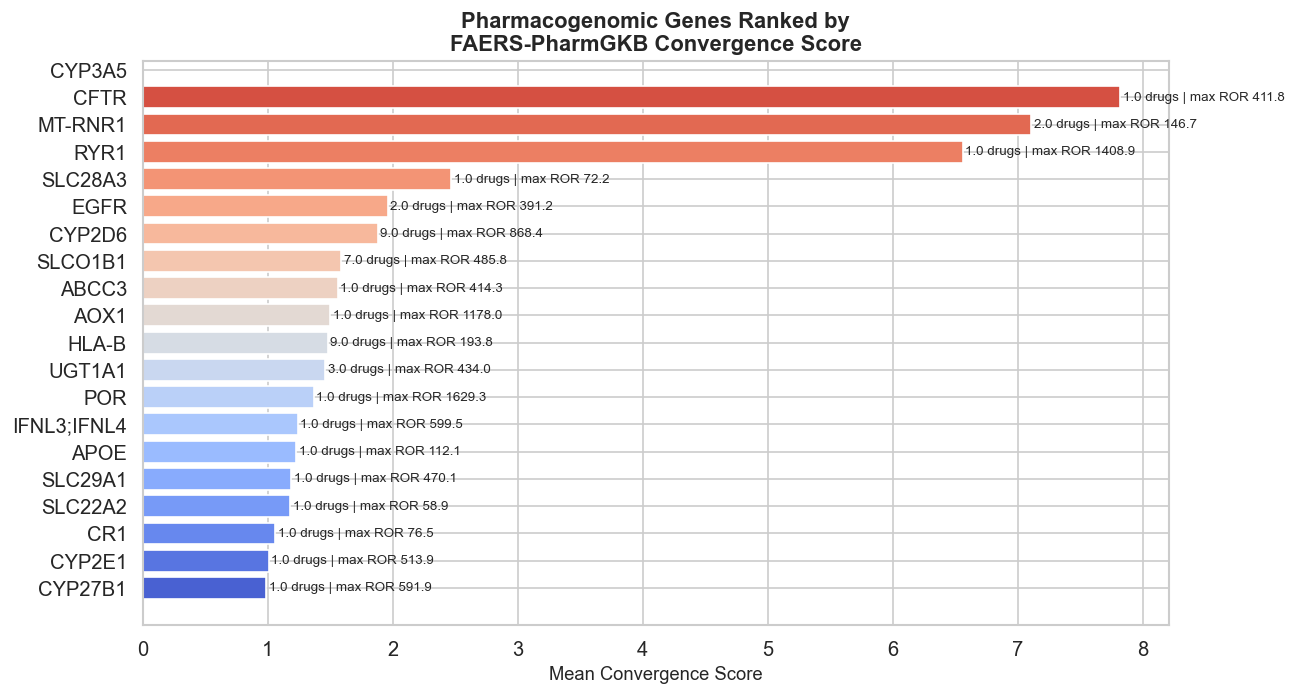

In [7]:
# ── Gene-level summary ────────────────────────────────────────────────────────
if not joined.empty and 'PGX_GENE' in joined.columns:
    gene_summary = (joined[joined['MATCH_CONFIDENCE']>=0.5]
                    .groupby('PGX_GENE')
                    .agg(
                        n_drug_ae_pairs=('CONVERGENCE_SCORE','count'),
                        mean_convergence=('CONVERGENCE_SCORE','mean'),
                        max_ror=('ROR','max'),
                        mean_ror=('ROR','mean'),
                        n_drugs=('DRUG','nunique'),
                    )
                    .round(2)
                    .sort_values('mean_convergence', ascending=False)
                    .head(20))
    
    print('Top genes by mean convergence score:')
    print(gene_summary.to_string())
    
    fig, ax = plt.subplots(figsize=(11,6))
    gene_plot = gene_summary.sort_values('mean_convergence')
    bars = ax.barh(gene_plot.index, gene_plot['mean_convergence'],
                   color=sns.color_palette('coolwarm', len(gene_plot)))
    ax.set_xlabel('Mean Convergence Score', fontsize=11)
    ax.set_title('Pharmacogenomic Genes Ranked by\nFAERS-PharmGKB Convergence Score', fontweight='bold')
    for bar, (gene, row) in zip(bars, gene_plot.iterrows()):
        ax.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                f"{row['n_drugs']} drugs | max ROR {row['max_ror']:.1f}",
                va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '04_gene_convergence.png')
    plt.show()

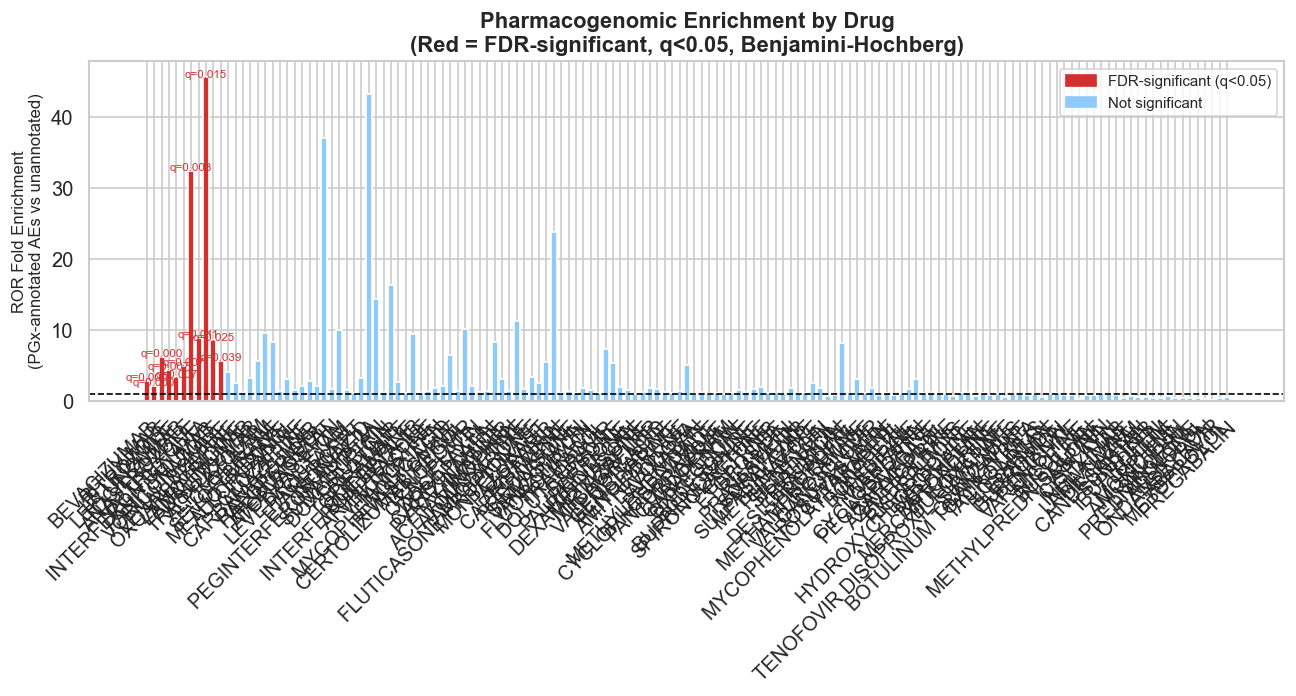

In [8]:
# ── Enrichment test visualization ─────────────────────────────────────────────
if 'enrich_test' in dir() and not enrich_test.empty and len(enrich_test) >= 3:
    fig, ax = plt.subplots(figsize=(11,6))
    
    colors_sig = ['#d32f2f' if s else '#90caf9' for s in enrich_test['significant_fdr']]
    bars = ax.bar(enrich_test['DRUG'], enrich_test['ror_fold_enrichment'],
                  color=colors_sig, edgecolor='white')
    ax.axhline(1, color='black', linestyle='--', lw=1)
    ax.set_ylabel('ROR Fold Enrichment\n(PGx-annotated AEs vs unannotated)', fontsize=10)
    ax.set_title('Pharmacogenomic Enrichment by Drug\n(Red = FDR-significant, q<0.05, Benjamini-Hochberg)',
                 fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    
    for bar, (_, row) in zip(bars, enrich_test.iterrows()):
        if row['significant_fdr']:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                    f'q={row["p_value_fdr_bh"]:.3f}', ha='center', fontsize=7, color='#d32f2f')
    
    sig_patches = [mpatches.Patch(color='#d32f2f', label='FDR-significant (q<0.05)'),
                   mpatches.Patch(color='#90caf9', label='Not significant')]
    ax.legend(handles=sig_patches, fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '05_enrichment_test.png')
    plt.show()
else:
    print('Enrichment test requires multiple drugs with matches — check join results above')

In [9]:
# ── Summary ───────────────────────────────────────────────────────────────────
print('=== Analysis Complete ===')
print(f'FAERS signals analyzed: {len(signals):,} ({signals["DRUG"].nunique()} drugs)')
print(f'PharmGKB annotations:   {len(pgx):,} ({pgx["DRUG"].nunique()} drugs)')
if not joined.empty:
    print(f'Matched pairs:          {len(joined):,}')
    print(f'High-confidence (>=0.5): {(joined["MATCH_CONFIDENCE"]>=0.5).sum():,}')
    print(f'Top convergence drug-AE: {joined.iloc[0]["DRUG"]} - {joined.iloc[0]["PT"]}')
print(f'\nFigures saved to: {FIGURES_DIR.resolve()}')
for f in sorted(FIGURES_DIR.glob('0[1-5]*.png')):
    print(f'  {f.name}')

=== Analysis Complete ===
FAERS signals analyzed: 58,368 (252 drugs)
PharmGKB annotations:   7,013 (658 drugs)
Matched pairs:          2,163
High-confidence (>=0.5): 1,717
Top convergence drug-AE: TACROLIMUS - PROPHYLAXIS AGAINST TRANSPLANT REJECTION

Figures saved to: C:\Users\James\Documents\GitHub\pharmacogenomics-signal-enrichment\data\figures
  01_pharmgkb_overview.png
  02_top_pgx_genes.png
  03_convergence_scores.png
  04_gene_convergence.png
  05_enrichment_test.png
